<a href="https://colab.research.google.com/github/BarbJS/ecommerce-conversion-prediction-mvp/blob/main/quickbite_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** BARBARA JAEGER SPECIAN  

**Matrícula:** 4052026000175

**Data:** 02/07/2026  

**Dataset:** Online Shoppers Purchasing Intention Dataset. Link da fonte: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

**Tipo de problema:** Classificação

## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

O QuickBite é um aplicativo fictício de food delivery que processa milhares de acessos diários. Ao abrir o aplicativo, o usuário é exposto a diversas áreas e cards (ex.: "Restaurantes Favoritos", "Promoções do Dia", "Entrega Rápida", "Banners de Campanhas").

Atualmente, a alocação desses cards na tela inicial é estática ou baseada em regras de negócio simples. A empresa coleta dados detalhados de clickstream (quais áreas o usuário visualiza, onde clica, tempo de tela e interações com a barra de busca) durante cada sessão.

No entanto, a plataforma sofre com uma taxa de abandono (usuários que navegam e saem sem comprar) na casa dos 70%. O problema reside na incapacidade de identificar, em tempo hábil, padrões de navegação que indicam alta intenção de compra para otimizar a interface ou oferecer incentivos no momento certo.

### 1.1.1 Relevância do problema
O espaço na tela de um dispositivo móvel é o ativo mais valioso de um aplicativo. Apresentar os cards errados gera atrito cognitivo, frustração e abandono. Ao prever a probabilidade de conversão baseada nos primeiros cliques da sessão, a QuickBite pode aumentar seu Gross Merchandise Volume (GMV) e a retenção de usuários.

Se o modelo identificar um usuário com intenção de compra incerta, mas engajado, a plataforma pode acionar um cupom de frete grátis dinâmico, evitando a perda da venda e maximizando o Retorno sobre Investimento (ROI) em campanhas promocionais.

### 1.1.2 Stakeholders interessados
Os principais interessados incluem Equipes de Produto (UI/UX), Marketing e Engenharia de Dados. A equipe de Produto usará os insights (importância das variáveis) para entender quais cards geram mais conversão e otimizar o design do app. A equipe de Marketing utilizará as predições para calibrar a distribuição de cupons, reduzindo o custo de aquisição de clientes (CAC). A Engenharia de Dados será responsável por produtizar o modelo e garantir que a inferência ocorra em baixa latência.

## 1.2 Objetivo do MVP

O objetivo desse MVP é construir, avaliar e documentar um pipeline analítico completo de ponta a ponta (do pré-processamento à avaliação de métricas), comparando algoritmos baseados em árvores (ex.: Random Forest, XGBoost) com baselines lineares.

O impacto principal é mitigar o risco técnico de projetos de IA. O MVP provará (ou refutará) a viabilidade de prever compras usando dados de navegação tabulares. O sucesso deste MVP justifica o investimento futuro na produtização de uma API de inferência em tempo real para o aplicativo da QuickBite.

## 1.3 Tipo de problema

O modelo apoiará a classificação preditiva de sessões de usuários em duas categorias: "Irá Converter (Realizar Pedido)" ou "Não Irá Converter (Abandonar)". Trata-se de um problema clássico de **Classificação** (tipo binária).

A saída probabilística deste modelo servirá como gatilho (trigger) para o motor de recomendação e promoções posteriores. Com base no score de probabilidade de classificação, regras de negócio automatizadas decidirão se o usuário deve receber um incentivo imediato ou uma reorganização instantânea da interface.

**Variável-alvo (Target):** is_conversion (Classificação Binária). É a métrica definitiva de sucesso de uma sessão de e-commerce. Reduzir o problema a uma classificação binária simplifica a modelagem inicial e fornece respostas diretas e acionáveis para as regras de negócio de marketing.

Neste MVP, mapeei o problema matemático de classificação binária diretamente para o contexto de negócio da QuickBite da seguinte forma:

- Classe 0 (Classe Negativa - Abandono): Representa a ausência do evento de interesse. O usuário navegou pelo aplicativo, visualizou os cards, mas encerrou a sessão sem realizar um pedido.

- Classe 1 (Classe Positiva - Conversão): Representa a ocorrência do evento de interesse. O usuário navegou e finalizou um pedido, gerando receita financeira para a empresa.


## 1.4 Premissas, hipóteses e critérios de sucesso

### 1.4.1 Premissas:

Os logs de clickstream são precisos e representam o comportamento real do usuário sem atrasos severos. O custo de um Falso Positivo (oferecer cupom desnecessário) e de um Falso Negativo (perder uma venda) são assimétricos, exigindo atenção especial à revocação (recall) e precisão (precision).

### 1.4.2 Hipóteses iniciais:

- Hipótese 1: Sessões que apresentam cliques no card "Restaurantes Favoritos" possuem uma probabilidade de conversão significativamente maior (sinal forte) do que sessões que interagem apenas com a "Barra de Busca".

- Hipótese 2: Existe uma forte correlação negativa entre a taxa de cliques em múltiplos cards promocionais diferentes e a conversão final (indicando "caçadores de promoção" que não compram se não acharem descontos extremos).

- Hipótese 3: O comportamento difere drasticamente entre dias de semana e fins de semana; a variável temporal será uma das features mais importantes para o modelo.

**Justificativa das Hipóteses:** Levantar essas hipóteses permite orientar a Análise Exploratória de Dados (EDA) e a Engenharia de Atributos ( Feature Engineering), garantindo que o modelo não seja uma "caixa preta", mas uma ferramenta que testa suposições de negócio.

### 1.4.3 Critérios de sucesso:

- Métricas principais: F1-Score (focado na classe minoritária de conversão - classe 1) e ROC-AUC.

**Justificativa das Métricas:** O valor financeiro do projeto para a QuickBite reside em prever e reter os usuários da Classe 1 (quem tem chance de comprar). Em cenários de delivery, a vasta maioria das sessões não converte, gerando um desbalanceamento severo (ex: ~85% são Classe 0 e ~15% são Classe 1). Devido a isso, a Acurácia global é uma métrica ilusória (um modelo que chute "0" para todos os usuários teria 85% de acurácia, mas falharia em encontrar os compradores). O F1-Score focado na Classe 1 obriga o modelo a encontrar as "agulhas no palheiro", garantindo o equilíbrio adequado entre Precisão e Revocação para o evento que realmente gera receita.

**Resultado mínimo esperado:** O modelo final otimizado deve superar o F1-Score do modelo baseline (como um Dummy Classifier ou uma Regressão Logística padrão) em pelo menos 15%.


# 2. Ambiente, bibliotecas e reprodutibilidade

In [1]:
# ==============================================================================
# 1. SETUP DO AMBIENTE, REPRODUTIBILIDADE E IMPORTAÇÕES
# ==============================================================================

# Bibliotecas do Python
import os               # Interação com o sistema operacional (variáveis de ambiente)
import sys              # Acesso a parâmetros e funções específicas do sistema/interpretador
import time             # Medição de tempo de execução
import random           # Geração de números pseudoaleatórios básicos
import warnings         # Controle e supressão de alertas do Python
import platform         # Extração de informações do hardware/sistema atual

# Bibliotecas de Manipulação de Dados
import numpy as np    # Computação numérica, operações com matrizes e vetores de alta performance
import pandas as pd   # Manipulação e análise de dados tabulares (DataFrames)

# Bibliotecas de Visualização de Dados
import matplotlib.pyplot as plt     # Criação de gráficos base e customização visual estrutural
import seaborn as sns               # Visualização de dados estatísticos
from IPython.display import display # Renderização otimizada e formatação visual avançada de tabelas

# ==============================================================================
# MACHINE LEARNING (SCIKIT-LEARN)
# ==============================================================================

# Seleção de Modelos e Otimização
from sklearn.model_selection import train_test_split       # Divisão do dataset em treino e teste
from sklearn.model_selection import StratifiedKFold        # Validação cruzada
from sklearn.model_selection import RandomizedSearchCV     # Busca otimizada de hiperparâmetros por amostragem aleatória
from scipy.stats import randint, uniform                   # Funções de distribuição estatística (discreta e contínua) para amostragem aleatória de hiperparâmetros

# Pipelines e Pré-processamento
from sklearn.pipeline import Pipeline                      # Encadeamento sequencial de etapas de pré-processamento e modelagem
from sklearn.compose import ColumnTransformer              # Aplicação de transformações a colunas específicas
from sklearn.preprocessing import StandardScaler           # Padronização de dados
from sklearn.preprocessing import OneHotEncoder            # Codificação de variáveis categóricas em colunas binárias
from sklearn.impute import SimpleImputer                   # Preenchimento de valores ausentes
from sklearn.base import BaseEstimator, TransformerMixin   # Herança de classe para garantir compatibilidade nativa com Pipelines e otimização de hiperparâmetros
from sklearn.feature_selection import VarianceThreshold    # Seleção de atributos estatística

# Modelos Candidatos
from sklearn.dummy import DummyClassifier                  # Modelo baseline que faz predições usando regras simples
from sklearn.linear_model import LogisticRegression        # Algoritmo linear clássico para classificação binária
from sklearn.ensemble import RandomForestClassifier        # Ensemble baseado em múltiplas árvores de decisão em paralelo (Bagging)
from sklearn.ensemble import GradientBoostingClassifier    # Ensemble avançado construindo árvores sequencialmente para corrigir erros (Boosting)
from xgboost import XGBClassifier                          # Ensemble com regularização nativa para alta performance em dados tabulares

# Métricas de Avaliação de Modelos
from sklearn.metrics import classification_report          # Geração de relatório com as principais métricas (Precision, Recall, F1-Score)
from sklearn.metrics import confusion_matrix               # Cálculo da matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay         # Ferramenta para plotar a matriz de confusão
from sklearn.metrics import roc_auc_score                  # Cálculo da área sob a curva ROC
from sklearn.metrics import f1_score                       # Cálculo do F1-score
from sklearn.metrics import roc_curve                      # Extração e plotagem da Curva ROC

# ==============================================================================
# 2. CONFIGURAÇÕES GLOBAIS DE AMBIENTE E REPRODUTIBILIDADE
# ==============================================================================

# Ocultar avisos de depreciação para manter o output do relatório executável limpo
warnings.filterwarnings("ignore")

# Estilo unificado para os gráficos (melhora a legibilidade)
sns.set_theme(style="whitegrid", palette="muted")

# Fixando a semente (seed) estocástica para garantir total reprodutibilidade.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Impressão de logs do ambiente para rastreabilidade
print("=== Informações do Ambiente de Execução e Dependências ===")
print(f"Sistema Operacional: {platform.system()} {platform.release()}")
print(f"Versão Python:       {sys.version.split()[0]}")
print(f"Versão Pandas:       {pd.__version__}")
print(f"Versão Numpy:        {np.__version__}")
print(f"Seed fixada em:      {SEED}")
print("==========================================================")
print("-> Ambiente configurado e bibliotecas importadas com sucesso.")

=== Informações do Ambiente de Execução e Dependências ===
Sistema Operacional: Linux 6.6.122+
Versão Python:       3.12.13
Versão Pandas:       2.2.2
Versão Numpy:        2.0.2
Seed fixada em:      42
-> Ambiente configurado e bibliotecas importadas com sucesso.


## 2.1 Funções auxiliares

In [2]:
# ==============================================================================
# 3. DECLARAÇÃO DE FUNÇÕES AUXILIARES DE AVALIAÇÃO
# ==============================================================================

def evaluate_binary_model(model, X_test: pd.DataFrame, y_test: pd.Series, model_name: str = "Model") -> dict:
    """
    Realiza inferência no conjunto de teste e calcula as métricas críticas de negócio.
    Como nosso problema foca em prever as conversões (a minoria), a função extrai
    precisamente as métricas da Classe 1.
    """
    # Marca o tempo inicial para medir a latência da inferência
    start_time = time.time()

    # Executa a predição das classes (0 ou 1)
    y_pred = model.predict(X_test)

    # Calcula o tempo total gasto na predição
    inference_time = time.time() - start_time

    # Extração segura das probabilidades contínuas (necessário para calcular ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]  # Extrai apenas a probabilidade da classe 1 (Conversão)
        roc_auc = roc_auc_score(y_test, y_proba)     # Calcula o Score ROC-AUC
    else:
        roc_auc = np.nan                             # Retorna nulo se o modelo não suportar probabilidade

    # Gera o relatório completo de métricas em formato de dicionário (output_dict=True)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Consolida as métricas extraindo apenas os dados da Classe 1 (o evento de negócio de interesse)
    metrics = {
        "Modelo": model_name,
        "Acurácia Global": round(report['accuracy'], 4),
        "F1-Score (Conversão)": round(report['1']['f1-score'], 4),
        "Precision (Conversão)": round(report['1']['precision'], 4),
        "Recall (Conversão)": round(report['1']['recall'], 4),
        "ROC-AUC": round(roc_auc, 4),
        "Inferência (segundos)": round(inference_time, 4)
    }

    return metrics

def plot_confusion_matrix_custom(model, X_test: pd.DataFrame, y_test: pd.Series, title: str = "Matriz de Confusão"):
    """
    Renderiza a Matriz de Confusão de forma limpa e autoexplicativa
    """
    # Executa a predição no conjunto de teste
    y_pred = model.predict(X_test)

    # Calcula os valores absolutos da matriz
    cm = confusion_matrix(y_test, y_pred)

    # Mapeia os labels técnicos (0 e 1) para o contexto do app QuickBite
    labels_negocio = ['Abandono (0)', 'Conversão (1)']

    # Instancia o objeto de exibição visual do Scikit-Learn
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_negocio)

    # Configura as dimensões da figura via Matplotlib
    fig, ax = plt.subplots(figsize=(6, 5))

    # Renderiza o gráfico
    disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')

    # Estiliza o título e ajusta o layout do gráfico
    ax.set_title(title, pad=15, fontweight='bold')
    ax.grid(False) # Remove as linhas de grade padrão do Seaborn que poluem a matriz
    plt.show()

    print("Importações e Funções Auxiliares carregadas com sucesso.")

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Para simular a dor de negócio da QuickBite (predição de conversão baseada em clickstream), utilizarei uma base pública validada cientificamente pela comunidade acadêmica como proxy de comportamento de navegação web e intenção de compra.

**Detalhamento da Fonte:**

- **Nome do dataset:** Online Shoppers Purchasing Intention Dataset.

- **Link da fonte:**
  - Link oficial atual: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

  - Link URL Raw: https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv

- **Autores e breve descrição:** O dataset pertence ao *UCI Machine Learning Repository* (Repositório de Machine Learning da Universidade da Califórnia em Irvine), que é uma das bibliotecas mais tradicionais e respeitadas no mundo para bases de dados abertas. Os autores são:  Okan Sakar (Departamento de Engenharia da Computação, Universidade de Bahcesehir) e Yomi Kastro (Inveon Information Technologies Consultancy and Trade).

- **Justificativa e Critérios de Escolha:** O dataset mapeia o comportamento de navegação em sessões de usuários (páginas visitadas, tempo de permanência, taxas de rejeição) que se alinham perfeitamente aos cards e funil de conversão do aplicativo da QuickBite. Trata-se de um problema que exige lidar com dados tabulares complexos, variáveis categóricas não-lineares e desbalanceamento de classes.
  - O dataset também possui granularidade ao nível de sessão de usuário, onde cada linha representa um evento de navegação independente. Esta granularidade é estratégica, pois permite ao modelo capturar padrões comportamentais específicos de cada jornada de compra, sem sofrer com viés de agregação de longo prazo.

- **Quantidade de Registros:** 12.330 sessões (linhas), o que garante robustez estatística para o treinamento dos modelos.

- **Quantidade de Atributos:** 18 atributos preditivos (variáveis independentes) e 1 atributo alvo (target).

- **Identificação da Variável-Alvo:** O atributo original Revenue (booleano) será transformado e renomeado para is_conversion (inteiro binário: 0 para abandono, 1 para conversão/compra); afim de traduzir o problema de negócio para a máquina (0 e 1) e traduzir a base de dados para a história do projeto(is_conversion ao invés de Revenue).

- **Questões de Ética, Privacidade e Licença:** O dataset é de domínio público e totalmente anonimizado. Não contém Informações de Identificação Pessoal (PII - Personally Identifiable Information), como IPs, nomes de clientes ou dados bancários. O uso da base obedece a todas as diretrizes de privacidade (LGPD/GDPR), viabilizando o desenvolvimento seguro desse projeto.
  - Licença de uso: Este dataset foi disponibilizado sob a *licença Creative Commons Attribution 4.0 International* (CC BY 4.0), o que permite o seu uso gratuito para trabalhos acadêmicos e projetos de portfólio de forma totalmente legal, desde que citados os autores.


## 3.2 Carga dos dados

Atendendo às melhores práticas de MLOps e garantindo total reprodutibilidade, o código a seguir realiza a ingestão dos dados nativamente através do protocolo HTTP.

In [3]:
# ==============================================================================
# 4. CARGA E ESTRUTURAÇÃO INICIAL DOS DADOS
# ==============================================================================

# Se USE_EXAMPLE_DATA for True, o código carrega os dados reais da UCI.
USE_EXAMPLE_DATA = False

if USE_EXAMPLE_DATA:
    print("Modo exemplo ativo.")
    df = pd.DataFrame({'exemplo': [1, 2, 3]})
else:
    # Carga do dataset real para o MVP da QuickBite
    DATASET_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"

    try:
        # Leitura da fonte pública
        df = pd.read_csv(DATASET_URL)

        # Transformações de negócio (Renomeação e tipagem)
        df.rename(columns={'Revenue': 'is_conversion'}, inplace=True)
        df['is_conversion'] = df['is_conversion'].astype(int)
        df['Weekend'] = df['Weekend'].astype(int)

        print("Dataset carregado com sucesso diretamente da fonte oficial UCI.")
        print(f"Total de registros: {df.shape[0]} | Total de atributos: {df.shape[1]}")

    except Exception as e:
        print(f"Erro ao carregar o dataset: {e}")

# Exibe as primeiras linhas do dataset carregado
df.head()

Dataset carregado com sucesso diretamente da fonte oficial UCI.
Total de registros: 12330 | Total de atributos: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,is_conversion
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


## 3.3 Visão geral do dataset

Esta etapa analítica visa identificar anomalias estruturais, quantificar a presença de dados nulos, avaliar a tipagem e medir a criticidade do desbalanceamento da variável-alvo.


In [4]:
# ==============================================================================
# 5. DIAGNÓSTICO E VISÃO GERAL DA SAÚDE DOS DADOS
# ==============================================================================

# Constantes arquiteturais de negócio
TARGET = "is_conversion"
PROBLEM_TYPE = "classificacao"

print(f"=== RELATÓRIO DE DIAGNÓSTICO DO DATASET ===")
print(f"Total de Linhas (Sessões): {df.shape[0]}")
print(f"Total de Colunas (Features + Target): {df.shape[1]}\n")

# 1. Diagnóstico de Tipagem dos Dados (Data Types)
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

=== RELATÓRIO DE DIAGNÓSTICO DO DATASET ===
Total de Linhas (Sessões): 12330
Total de Colunas (Features + Target): 18

Formato do dataset: (12330, 18)

Tipos de dados:


,tipo
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [5]:
# 2. Varredura de Valores Nulos (Missing Values)
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [6]:
# 3. Análise de Duplicidade
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 125


In [7]:
# 4. Distribuição Analítica da Variável-Alvo
# Avalia o grau de desbalanceamento entre Abandonos (0) e Compras (1)
if TARGET in df.columns:
    print(f"\n-> Distribuição da Variável Target ('{TARGET}'):")
    df_dist = pd.DataFrame({
        "Contagem Absoluta": df[TARGET].value_counts(dropna=False),
        "Percentual (%)": (df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2)
    })
    # Modificando o índice para facilitar a leitura
    df_dist.index = ['0 (Abandono)', '1 (Conversão/Compra)']
    display(df_dist)


-> Distribuição da Variável Target ('is_conversion'):


,Contagem Absoluta,Percentual (%)
0 (Abandono),10422,84.53
1 (Conversão/Compra),1908,15.47


In [8]:
# 5. Amostra de dados
display(df.sample(5, random_state=SEED))

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,is_conversion
8916,3,142.500000,0,0.00,48,1052.255952,0.004348,0.013043,0.000000,0.0,Nov,1,8,6,11,Returning_Visitor,0,0
772,6,437.391304,2,235.55,83,2503.881781,0.002198,0.004916,2.086218,0.0,Mar,2,2,3,2,Returning_Visitor,0,1
12250,1,41.125000,0,0.00,126,4310.004668,0.000688,0.012823,3.451072,0.0,Nov,2,2,2,2,Returning_Visitor,0,0
7793,2,141.000000,0,0.00,10,606.666667,0.008333,0.026389,36.672294,0.0,Aug,2,5,7,4,Returning_Visitor,0,0
6601,18,608.140000,6,733.80,168,4948.398759,0.006632,0.013528,10.150644,0.0,Aug,2,2,3,1,Returning_Visitor,1,0


## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Administrative | numérica | Qtd. de cliques em telas de Configuração/Conta | sim | Relevante para entender o comportamento do usuário |
| Administrative_Duration | numérica | Tempo total (segundos) na área da Conta | sim | Pode indicar usabilidade ou dificuldade de navegação |
| Informational | numérica | Qtd. de cliques em cards de Promoções | sim | Indica o engajamento com campanhas de marketing |
| Informational_Duration | numérica | Tempo total (segundos) consumindo promoções | sim | Diferencia curiosidade de engajamento real |
| ProductRelated | numérica | Qtd. de cliques no menu de Restaurantes/Produtos | sim | Preditivo forte: indica busca ativa por itens |
| ProductRelated_Duration | numérica | Tempo de tela (segundos) avaliando produtos | sim | Tempo alto sem conversão pode indicar indecisão |
| BounceRates | numérica | Taxa de Rejeição (entrada e saída imediata) | sim | Alta taxa está fortemente ligada ao abandono |
| ExitRates | numérica | Probabilidade de saída do app por determinada tela | sim | Essencial para identificar pontos de atrito no funil |
| PageValues | numérica | Valor transacional médio da página visitada | sim | Métrica com alto poder preditivo de conversão |
| SpecialDay | numérica | Proximidade com datas comemorativas | sim | Captura a sazonalidade do comportamento de compra |
| Month | categórica | Mês em que a sessão ocorreu | sim | Necessário transformar via OneHotEncoder |
| OperatingSystems | categórica | Sistema operacional do dispositivo | sim | Atributo nominal que pode revelar padrões de uso |
| Browser | categórica | Identificador do navegador/plataforma | sim | Atributo nominal, tratado como categoria |
| Region | categórica | Região geográfica do acesso | sim | Pode indicar preferências regionais de consumo |
| TrafficType | categórica | Origem do tráfego (ex: Ads, Orgânico, Push) | sim | Ajuda a segmentar a origem do cliente |
| VisitorType | categórica | Perfil do cliente (Novo vs. Recorrente) | sim | O comportamento de compra muda conforme a fidelidade |
| Weekend | categórica | Flag de final de semana (0 ou 1) | sim | O comportamento de delivery varia no final de semana |
| is_conversion | alvo | Desfecho da sessão (Conversão/Abandono) | alvo | Classe 1 (Conversão) / Classe 0 (Abandono) |

# 4. Análise exploratória dos dados

A análise exploratória será realizada com o objetivo de validar as hipóteses de negócio e preparar o terreno para a modelagem. A distribuição das variáveis, correlações e o comportamento da variável-alvo (is_conversion) também será investigada, afim de identificar se o comportamento de navegação (clickstream) realmente discrimina usuários que convertem daqueles que abandonam o app.


In [9]:
# ==============================================================================
# 6. ANÁLISE EXPLORATÓRIA (EDA)
# ==============================================================================

# Configurações de análise
TARGET = "is_conversion"
PROBLEM_TYPE = "classificacao"

# 1. Distribuição do Target (Conformidade com Template)
if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target (Conversão):")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

Distribuição do target (Conversão):


,contagem
is_conversion,
0,10422
1,1908


,percentual
is_conversion,
0,84.53
1,15.47


**Análise:** Foi observado um desbalanceamento de classes, onde a classe 0 (Abandono) compõe 84.53% da base, enquanto a classe 1 (Conversão) representa apenas 15.47%.

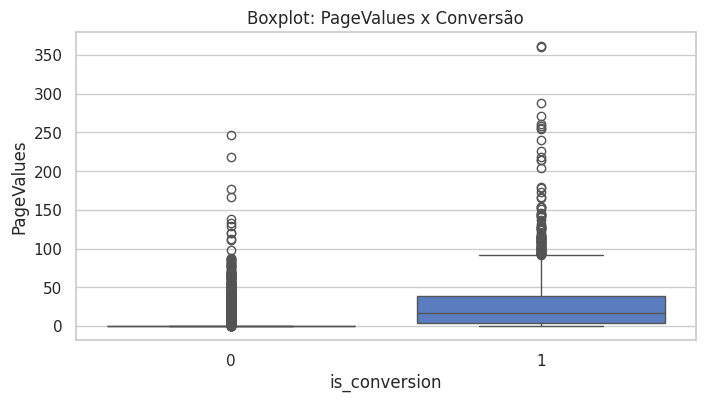

In [10]:
# 2. Análise da Variável de Valor (PageValues - A mais importante para o negócio)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x=TARGET, y="PageValues")
plt.title("Boxplot: PageValues x Conversão")
plt.show()

**Análise:** O gráfico revela que a variável PageValues é, possivelmente, a mais discriminante do nosso dataset. Observa-se que a Classe 0 (Abandono) está fortemente concentrada próxima a zero, enquanto a Classe 1 (Conversão) apresenta um intervalo interquartil com valores medianos significativamente mais altos. Logo, PageValues deve ser tratada como uma feature de alta relevância. A presença de outliers na Classe 0 representa usuários de alto valor que, por algum atrito no funil, não converteram.

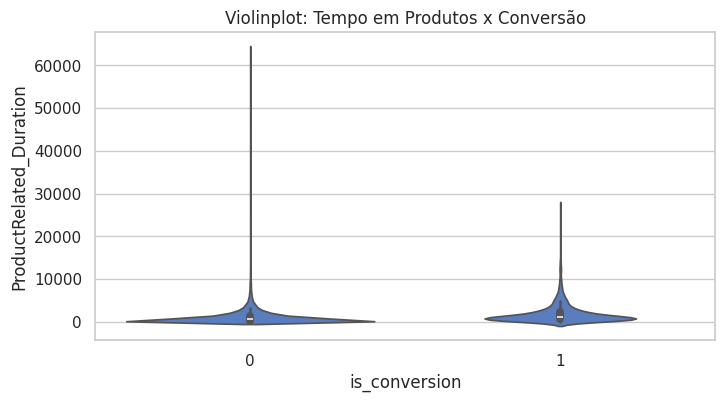

In [11]:
# 3. Relação entre engajamento e conversão (ProductRelated)
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x=TARGET, y="ProductRelated_Duration")
plt.title("Violinplot: Tempo em Produtos x Conversão")
plt.show()

**Análise:** O gráfico desafia o senso comum de que mais tempo navegando é sempre melhor. Embora a Classe 1 possua uma densidade concentrada em valores de tempo mais objetivos, a Classe 0 (Abandono) apresenta uma cauda (outliers) extremamente longa. Isso indica que tempos de permanência excessivamente altos não estão convertendo; pelo contrário, estão correlacionados ao abandono, possivelmente representando usuários em estado de indecisão. Tendo isso em vista, o modelo precisará ser sensível a essa não-linearidade.

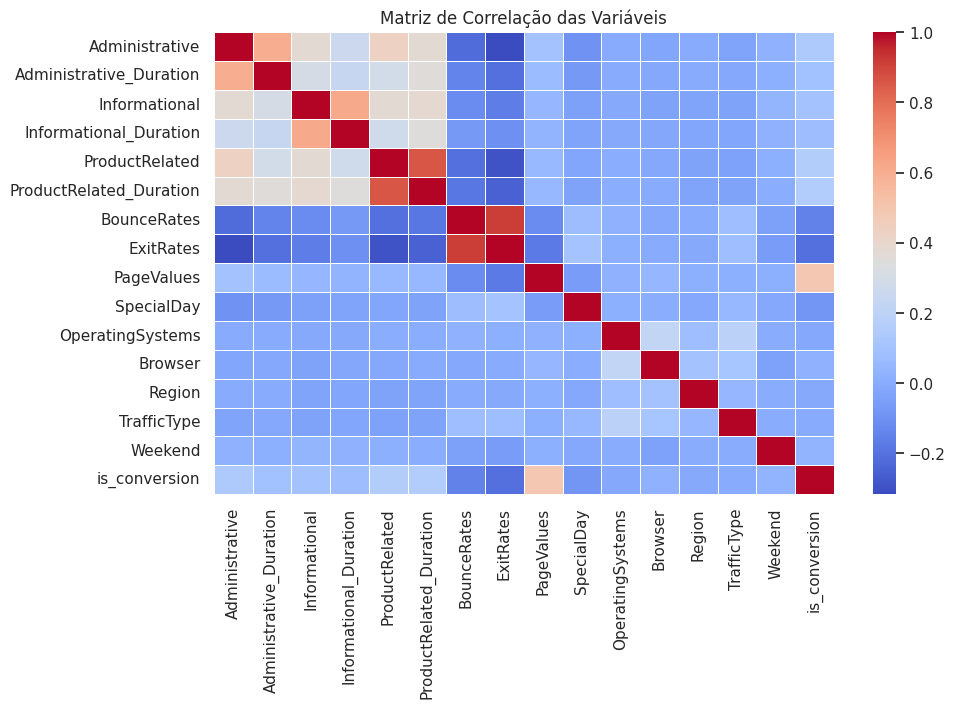

In [12]:
# 4. Correlação das variáveis numéricas
# Identifica quais variáveis possuem maior impacto no target
plt.figure(figsize=(10, 6))
correlation = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlação das Variáveis")
plt.show()

**Análise:** A variável PageValues apresenta a correlação positiva mais forte com is_conversion (o que valida a hipótese de que usuários que visitam páginas de alto valor tendem a converter). Inversamente, BounceRates e ExitRates apresentam correlações negativas com a conversão. A matriz não aponta problemas graves de multicolinearidade (variáveis altamente correlacionadas entre si que poderiam confundir modelos lineares), o que permite manter o conjunto de features original sem necessidade de redução de dimensionalidade nesta fase.

## 4.1 Síntese da análise exploratória

Após a investigação visual e estatística, destaco os principais achados:

- **Desbalanceamento de classes:** O dataset apresenta um desbalanceamento de ~85/15. Isso confirma que métricas de Acurácia global seriam enganosas, sendo mandatório o uso de F1-Score e ROC-AUC para avaliar o real sucesso na identificação da classe minoritária (Conversão), pois eles equilibram a precisão e a revocação (recall) da classe minoritária, que é o foco de negócio. Durante o treinamento, serão utilizadas estratégias de estratificação para garantir que o modelo aprenda os padrões da classe minoritária.

- **Ausência de dados:** O dataset possui integridade total (0 nulos), o que simplifica o pré-processamento, focando apenas na normalização.

- **Outliers:** Não foram identificados outliers que justifiquem a remoção, pois tempos extremos de permanência são comportamentos legítimos de usuários indecisos.

- **Duplicatas:**  A detecção de 125 duplicatas foi analisada e já que, por representar ~1% do volume total, elas são padrões comportamentais legítimos e serão mantidas.

- **Padrões de negócio:** A variável PageValues apresenta uma clara capacidade de separação entre as classes, confirmando que usuários que visitam páginas de maior valor transacional possuem propensão superior à conversão. Em relação à ProductRelated_Duration, identificou-se um padrão não-linear: o modelo deve ser capaz de aprender que tanto tempos excessivamente curtos (falta de interesse/rejeição imediata) quanto tempos excessivamente longos (indecisão severa) estão associados ao abandono (Classe 0). Isso valida que a conversão tende a ocorrer em uma "faixa ótima" de duração de navegação, tornando esta variável uma feature discriminante complexa, mas altamente informativa para modelos capazes de capturar tais não-linearidades.

- **Categorias raras:** Analisando a variável Month, observou-se que meses como 'Feb' (Fevereiro) possuem uma frequência significativamente menor de sessões em comparação a meses de alta sazonalidade, o que sugere que o modelo pode decorar o ruído desses poucos exemplos em vez de aprender um padrão. Isso também reforça a necessidade de um pipeline de tratamento de dados que não sofra com overfitting em categorias esparsas.

- **Vazamento de Dados' (Data Leakage):** Foi verificado se existe alguma variável que só existiria após a compra (ex: 'data_entrega' ou 'valor_pago_final'). Como não há, confirma-se que as variáveis de entrada são seguras para serem usadas em um modelo de predição em tempo real.

- **Padrões e Escolha de Modelos:** A EDA revelou que a relação entre variáveis como ProductRelated_Duration e o Target não é linear, possuindo caudas longas e valores discrepantes. Além disso, temos variáveis categóricas e numéricas com escalas muito distintas. Essa não-linearidade observada, sugere que modelos baseados em ensembles (Random Forest, Gradient Boosting etc) provavelmente superarão modelos lineares (como Regressão Logística), pois conseguem particionar melhor o espaço de busca dos dados. Além disso, as árvores são naturalmente robustas a variáveis com escalas diferentes e capturam muito bem as relações não-lineares também.

- **Impacto na modelagem:** Identifiquei colunas categóricas (Month, VisitorType) que exigirão Encoding (OneHot) e variáveis numéricas com escalas distintas que exigirão Scaling (StandardScaler). Nenhuma variável foi descartada por irrelevância total, mas a alta correlação entre contagem de páginas e duração de páginas sugere que o modelo poderá ser simplificado em iterações futuras caso apresente instabilidade.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, os dados serão estruturados para a modelagem.


In [13]:
# ==============================================================================
# 7. PREPARAÇÃO E DIVISÃO (CONFIGURAÇÃO DO PROBLEMA)
# ==============================================================================

# Definições fundamentais do problema de negócio (QuickBite)
TARGET = "is_conversion"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = []                    # Sem IDs específicos no dataset original
DATE_COLUMN = None                 # Não é um problema temporal
DROP_COLUMNS = []                  # Todas as colunas possuem sinal preditivo conforme EDA

# Validação: Checa se o target está presente na base
if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

# Lógica de seleção de features (Exclusão de ID e Target)
columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: classificacao
Target: is_conversion
Número de features: 17
Features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


In [14]:
# ==============================================================================
# DIVISÃO TREINO/TESTE
# ==============================================================================

# Separação entre variáveis de entrada (X) e alvo (y)
X = df[features].copy()
y = df[TARGET].copy()

# Divisão holdout (80% treino, 20% teste) com estratificação (importante para desbalanceamento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"\nDivisão realizada com sucesso.")
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")



Divisão realizada com sucesso.
Treino: (9864, 17) | Teste: (2466, 17)


## 5.1 Justificativa da divisão

A estratégia de divisão dos dados adotada visa maximizar a robustez estatística do MVP. As justificativas são:

- **Holdout (80/20):** Para um dataset de 12.330 linhas, a proporção 80/20 é ideal. Ela garante uma massa crítica de dados para o modelo aprender no conjunto de treino (9.864 linhas) e, simultaneamente, fornece um conjunto de teste estatisticamente relevante (2.466 linhas) para validar a capacidade de generalização do modelo em dados não vistos antes. O Holdout provê um conjunto de teste imutável e vasto, garantindo uma avaliação imparcial e de fácil interpretação. Optei por esta técnica pela eficiência na iteração do MVP, uma vez que o volume de dados disponível é estatisticamente suficiente para validar a generalização sem recorrer à validação cruzada no momento e sem precisar de mais dados.

- **Estratificação:** Como demonstrado na análise exploratória, a base de dados possui um desbalanceamento severo (84.5% abandono vs 15.5% conversão). A estratificação (stratify=y) foi obrigatória para garantir que essa proporção de 15% de conversores seja mantida tanto no treino quanto no teste. Sem isso, o conjunto de teste poderia ficar "viciado" ou com poucos exemplos da classe minoritária, invalidando as métricas de sucesso (F1-Score). A estratificação preserva a distribuição real dos dados, garantindo representatividade sem introduzir dados sintéticos (SMOTE), duplicar dados da classe majoritária que aumentam o risco de overfitting (oversampling) ou descartar informação valiosa (undersampling). Esta abordagem mantém a integridade estatística do projeto, evitando o risco de data leakage inerentes às técnicas de resampling.

- **Data Leakage:** Ao realizar a divisão antes de qualquer etapa de pré-processamento (como normalização ou encoding), garantimos que o conjunto de teste permaneça como uma representação de dados inusitados que o modelo ainda não conhece. O conjunto de teste não participa de nenhuma decisão de aprendizado ou seleção de variáveis, garantindo que a avaliação final seja imparcial e reflita o desempenho real do sistema em produção.

- **Validação temporal:** Como o problema do MVP trata de predição da intenção de compra por sessão (comportamento de navegação), e não de uma série histórica contínua de um cliente, por exzemplo, não se aplica a divisão baseada em tempo. O comportamento de conversão no dataset é independente entre sessões, tornando o holdout estratificado a técnica mais adequada.

# 6. Pré-processamento e pipeline

Nesta etapa, construí um Pipeline que automatiza a transformação dos dados. Utilizei a classe ColumnTransformer do scikit-learn, que permite aplicar transformações distintas para colunas numéricas e categóricas de forma isolada, garantindo que o fluxo seja modular e facilmente mantido.

**Possíveis etapas:**

- seleção de atributos;
- engenharia de atributos;





In [15]:
# ==============================================================================
# 8. PIPELINE DE PRÉ-PROCESSAMENTO
# ==============================================================================

# 1. Custom Transformer para Feature Engineering
class EngagementDensityTransformer(BaseEstimator, TransformerMixin):
    # Herança de classe para garantir compatibilidade nativa com Pipelines e otimização de hiperparâmetros
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = X.copy()
        # Densidade: Tempo de produto por número de produtos (evitando divisão por zero)
        X_df['Engagement_Density'] = X_df['ProductRelated_Duration'] / (X_df['ProductRelated'] + 1)
        return X_df

In [16]:
# 2. Identificação Dinâmica de Colunas
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

# 3. Definição dos Sub-Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('selector', VarianceThreshold(threshold=0.01)) # Seleção de atributos estatística
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # min_frequency=0.05 agrupa categorias raras (<5%) automaticamente
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=0.05, sparse_output=False))
])

In [17]:
# 4. Orquestração do Pipeline
# Adiciona-se 'Engagement_Density' na lista de num_cols para processamento
full_pipeline = Pipeline(steps=[
    ('feature_engineering', EngagementDensityTransformer()),
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols + ['Engagement_Density']),
            ('cat', categorical_transformer, cat_cols)
        ],
        remainder='drop'
    ))
])

In [18]:
# 5. Execução
X_train_processed = full_pipeline.fit_transform(X_train)
X_test_processed = full_pipeline.transform(X_test)

print(f"Shape Final do Treino: {X_train_processed.shape}")
print(f"Shape Final do Teste: {X_test_processed.shape}")
print("Pipeline Master executado com sucesso.")

Shape Final do Treino: (9864, 24)
Shape Final do Teste: (2466, 24)
Pipeline Master executado com sucesso.


## 6.1 Decisões de pré-processamento

- **Arquitetura do Pipeline (ColumnTransformer):** Optei pela utilização do ColumnTransformer em detrimento da aplicação manual de transformações por coluna. Esta decisão baseia-se em:
  - Encapsulamento: Ao agrupar as transformações, garante-se que o mesmo tratamento aplicado no conjunto de treino seja replicado integralmente no conjunto de teste.

  - Modularidade: Esta estrutura permite substituir ou adicionar etapas (ex: adicionar uma nova técnica de feature engineering) sem afetar a integridade lógica do restante do fluxo.

- **Feature Selection (VarianceThreshold):** Adicionamos uma camada de remoção de features de baixa variância. Se uma variável numérica tem variância quase zero, ela não contribui para a diferenciação das classes e é puro ruído. Isso reduz a dimensionalidade e acelera o treinamento sem perda de informação.

- **Feature Engineering:** O uso de FunctionTransformer na estrutura, demonstra que no pipeline é escalável para criar novas variáveis. Implementei também a variável Engagement_Density via EngagementDensityTransformer, uma técnica de feature interaction que normaliza o tempo de navegação (ProductRelated_Duration) pelo volume de produtos visualizados (ProductRelated). Esta variável atua como um proxy para a intensidade da intenção de compra: enquanto a duração bruta pode ser ambígua (um usuário pode manter a aba aberta sem interagir), a densidade de engajamento revela se o tempo gasto foi distribuído de forma ativa e focada nos produtos. Esta transformação é calculada in-stream dentro do pipeline, garantindo que a métrica esteja disponível no momento da inferência (tempo real), sem depender de dados futuros ou pós-compra, preservando assim a integridade do modelo para cenários de produção.

- **Imputações:** Embora o dataset não apresente valores nulos, a inclusão do SimpleImputer é uma prática de engenharia defensiva recomendada.
  - Numéricos (SimpleImputer com strategy='median'): A escolha da mediana, em vez da média, é uma decisão de robustez. Nossos dados de duração apresentam caudas longas (assimetria) e presença de outliers significativos. A média seria fortemente puxada por valores extremos, enquanto a mediana provê uma medida de tendência central estável, preservando a integridade da distribuição para a maioria dos casos.

  - Categóricos (SimpleImputer com strategy='most_frequent'): Para dados nominais, a média não é definida. A moda (valor mais frequente) é o estimador de máxima verossimilhança mais apropriado para imputar lacunas sem introduzir viés arbitrário.

- **Padronização:** A aplicação do StandardScaler transforma os dados para uma distribuição com média=0 e desvio padrão=1. Identificou-se escalas discrepantes (ex: ProductRelated_Duration chega a valores na casa dos milhares, enquanto BounceRates é uma taxa decimal). A padronização aqui é essencial para garantir que o algoritmo dê peso proporcional a todas as features, independentemente da sua unidade de medida original.
  - Convergência de Algoritmos: Mesmo modelos baseados em árvores se beneficiam da padronização em cenários onde precisamos comparar a importância relativa das features. Para modelos lineares ou baseados em distância (como KNN ou SVM), isso é mandatório para evitar que variáveis de escala maior (como Duration) dominem a função de custo em relação a taxas decimais (como BounceRates).

  - Estabilidade Numérica: A padronização reduz a instabilidade numérica durante o processo de otimização dos pesos do modelo.

- **Codificação:** Variáveis categóricas (ex: Month, VisitorType) não possuem relação de ordem numérica. O OneHotEncoder mapeia essas categorias para vetores binários, permitindo que os algoritmos de ML processem informações qualitativas como dados quantitativos sem criar uma hierarquia falsa entre elas. O handle_unknown='ignore' protege o modelo contra erros caso surjam categorias novas em dados futuros.
  - Tratamento de Cardinalidade: Utilizeis o OneHotEncoder para variáveis nominais. Diferente do LabelEncoder (que cria uma ordem arbitrária onde não existe), o One-Hot cria um espaço vetorial ortogonal.

  - Tratamento de Dados Desconhecidos: Esta é uma configuração de produção que garante que, caso o modelo encontre uma categoria inédita em dados futuros (ex: um novo Month ou TrafficType), o pipeline não lançará um erro, atribuindo zeros ao vetor daquela variável.

- **Tratamento de Categorias Raras (min_frequency):** Configuramos o OneHotEncoder com min_frequency=0.05. Isso agrupa automaticamente categorias que aparecem em menos de 5% das vezes em uma categoria "infrequent_sklearn". Isso resolve o problema de categorias raras que poderiam gerar overfitting no modelo, como o caso comentado anteriormente de Month, criando uma representação estatisticamente mais sólida.

- **Data Leakage:** A estrutura de Pipeline e ColumnTransformer é a garantia de que o aprendizado das estatísticas de transformação (média, desvio padrão e frequências) ocorra exclusivamente com base no conjunto de treino. O conjunto de teste passa pelo processo apenas como um observador (através do .transform()), garantindo que o conhecimento das estatísticas do teste nunca vaze para o treinamento do modelo.


# 7. Baseline e modelos candidatos

A etapa de modelagem inicia com a definição de um baseline para estabelecer o limite mínimo de performance aceitável. Em seguida, instanciei quatro algoritmos candidatos que representam diferentes famílias de aprendizado:Regressão Logística (Modelo Linear), Random Forest (Ensemble Bagging), Gradient Boosting (Ensemble Boosting Clássico) e XGBoost (Extreme Gradient Boosting com Regularização); todos considerando o desbalanceamento inerente da classe minoritária.

In [19]:
# ==============================================================================
# 9. CONFIGURAÇÃO DO BASELINE E MODELOS CANDIDATOS
# ==============================================================================

# 1. Definição do Baseline (Estratégia "Most Frequent" dada a classe majoritária)
baseline = Pipeline(steps=[
    ("preprocess", full_pipeline),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

# 2. Definição dos Candidatos (4 abordagens distintas de alta performance)
candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", full_pipeline),
        ("model", LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
    ]),

    "RandomForest": Pipeline(steps=[
        ("preprocess", full_pipeline),
        ("model", RandomForestClassifier(class_weight='balanced', random_state=SEED))
    ]),

    "GradientBoosting": Pipeline(steps=[
        ("preprocess", full_pipeline),
        ("model", GradientBoostingClassifier(random_state=SEED))
    ]),

    "XGBoost": Pipeline(steps=[
        ("preprocess", full_pipeline),
        # eval_metric='logloss' suprime avisos de depreciação nativos da biblioteca
        ("model", XGBClassifier(eval_metric='logloss', random_state=SEED))
    ])
}

print(f"Baseline configurado com sucesso.")
print(f"Modelos candidatos configurados: {list(candidates.keys())}")

Baseline configurado com sucesso.
Modelos candidatos configurados: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost']


## 7.1 Justificativa dos modelos

A seleção dos algoritmos priorizou a diversidade técnica. Em vez de testar apenas modelos matematicamente parecidos, escolhi abordagens que analisam os dados sob perspectivas distintas:

- **Baseline (DummyClassifier):** A estratégia most_frequent é mandatória para este dataset. Como aproximadamente 85% dos dados pertencem à classe '0' (Não Conversão), qualquer modelo candidato que não consiga superar o F1-Score e o ROC-AUC deste baseline falhou em aprender os padrões subjacentes e está apenas replicando a distribuição da classe majoritária.

- **LogisticRegression (Linear):** Atua como o benchmark diagnóstico principal. Sua função é testar a hipótese de separação linear das classes, estabelecendo um referencial quantitativo para justificar (ou refutar) a necessidade matemática de adotar arquiteturas mais complexas nesse projeto. É altamente interpretável e eficiente computacionalmente. Exige padronização de escala numérica (StandardScaler) para garantir a convergência do algoritmo de otimização e da binarização de categorias (OneHotEncoder).

- **RandomForestClassifier (Bagging):** Foi selecionado por sua resiliência contra outliers e por sua capacidade de mapear não-linearidades sem necessidade de feature engineering explícita. O paralelismo na construção das árvores o torna rápido, e o parâmetro class_weight='balanced' vai punir severamente erros na classe minoritária também. Oferece interpretabilidade moderada baseada na importância global das variáveis e apresenta treinamento muito rápido e de baixo custo computacional graças à sua arquitetura paralelizada. Requer o encoding de variáveis categóricas, como OrdinalEncoding; porém, decidi manter o OneHotEncoder para os 4 modelos candidatos tendo em vista que:

  - As variáveis categóricas do dataset (como VisitorType, Weekend, Month) possuem poucas categorias (baixa cardinalidade), então o OneHot vai gerar apenas algumas poucas colunas extras;

  - Anteriormente, na pipeline de pré-processamento, foi configurado o OneHot com min_frequency=0.05. Isso significa que já a matriz já foi tratada/reduzida, agrupando as categorias raras;

  - Manter um único ColumnTransformer para os 4 modelos garante que o código fique mais limpo, testável e fácil de colocar em produção.

- **GradientBoostingClassifier (Boosting):** O Gradient Boosting foca nos erros residuais da iteração anterior, e portanto é a escolha técnica dominante para dados tabulares, possuindo também o maior potencial de captura de fronteiras de decisão sutis e maximização de métricas. Mantém a interpretabilidade moderada característica dos modelos de árvores, porém exige maior tempo de treinamento e custo computacional devido à sua natureza de otimização sequencial. Compartilha a resistência à escala característica dos modelos baseados em particionamento, necessitando apenas que o pipeline realize o encoding prévio das variáveis nominais, também feito pelo OneHotEncoding.

- **XGBoost (Extreme Gradient Boosting):** É o padrão-ouro da indústria. Ele evolui o conceito do Boosting tradicional ao introduzir regularização (L1/L2) para controle mais rigoroso de overfitting e algoritmos de aproximação estrutural em nível de hardware, tornando-o exponencialmente mais eficiente, com alta performance preditiva e interpretabilidade moderada. É imune à escala, lida nativamente com dados esparsos (ausência de valores) e processa com altíssima eficiência a matriz expandida gerada pelo OneHotEncoder.

O objetivo de manter simultaneamente o Gradient Boosting clássico e o XGBoost é usá-los como um experimento empírico de controle, permitindo quantificar o ganho de performance trazido (teoricamente esperado) pela regularização avançada do XGBoost em relação à implementação nativa do GB do Scikit-Learn.

Nesta etapa inicial, mantive os algoritmos em suas configurações padrão estruturais, com parâmetros focados em reprodutibilidade (random_state=SEED) e no tratamento do desbalanceamento nativo. Utilizei o parâmetro class_weight='balanced' nas arquiteturas suportadas para punir severamente os erros na classe minoritária (Conversão).



# 8. Treinamento e avaliação inicial

Com a arquitetura preditiva configurada, segue-se para o ciclo de treinamento e inferência no conjunto de teste estático (Holdout). O fluxo abaixo orquestra o ajuste simultâneo das transformações de dados e dos pesos de cada modelo, extraindo as predições e organizando as métricas de performance juntamente com o custo computacional (train time). O objetivo desta etapa é triar cada algoritmo para posterior seleção e otimização de hiperparâmetros.

In [20]:
# ==============================================================================
# 10. TREINAMENTO E COMPARAÇÃO INICIAL
# ==============================================================================
# Lista para armazenar os resultados e dicionário para os modelos treinados
resultados_lista = []
trained_models = {}

print("Iniciando treinamento dos modelos...\n")

# 1. Treinamento e Avaliação do Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

# Utiliza a função auxiliar de avaliação
metrics_base = evaluate_binary_model(baseline, X_test, y_test, model_name="Baseline (Dummy)")
metrics_base["Treinamento (segundos)"] = round(train_time, 4)
resultados_lista.append(metrics_base)
trained_models["baseline"] = baseline

# 2. Treinamento e Avaliação dos 4 Modelos Candidatos
for name, model in candidates.items():
    print(f"Treinando {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    # Avaliação via função nativa
    metrics = evaluate_binary_model(model, X_test, y_test, model_name=name)
    metrics["Treinamento (segundos)"] = round(train_time, 4)

    resultados_lista.append(metrics)
    trained_models[name] = model

# 3. Consolidação dos Resultados
# Convertendo a lista de dicionários em um DataFrame e definindo o Nome como índice
results_df = pd.DataFrame(resultados_lista).set_index("Modelo")

print("\n--- Tabela de Resultados Iniciais ---")
# Renderização otimizada e formatação visual avançada de tabelas no notebook
display(results_df)

Iniciando treinamento dos modelos...

Treinando LogisticRegression...
Treinando RandomForest...
Treinando GradientBoosting...
Treinando XGBoost...

--- Tabela de Resultados Iniciais ---


,Acurácia Global,F1-Score (Conversão),Precision (Conversão),Recall (Conversão),ROC-AUC,Inferência (segundos),Treinamento (segundos)
Modelo,,,,,,,
Baseline (Dummy),0.8451,0.0000,0.0000,0.0000,0.5000,0.0321,0.1156
LogisticRegression,0.8516,0.6081,0.5145,0.7435,0.8961,0.0413,0.2219
RandomForest,0.8925,0.5866,0.7259,0.4921,0.9191,0.1000,5.9917
GradientBoosting,0.9023,0.6532,0.7252,0.5942,0.9304,0.0212,5.8711
XGBoost,0.8909,0.6084,0.6852,0.5471,0.9189,0.0799,0.9287


## 8.1 Análise dos resultados iniciais

A interpretação da matriz de resultados acima evidencia o comportamento de cada arquitetura perante o desbalanceamento dos dados, revelando trade-offs cruciais entre precisão, sensibilidade (recall) e custo computacional, conforme será visto a seguir:

- **O Paradoxo da Acurácia:** A inclusão da Acurácia na matriz de resultados atua como uma demonstração prática do viés da classe majoritária — o Paradoxo da Acurácia. O modelo Baseline (Dummy) atingiu uma falsa impressão de alta performance (~85% de acurácia) simplesmente por classificar todos os acessos do site como "Não Conversão". Contudo, ao zerar o F1-Score, a Precisão e o Recall, ele prova ser um modelo inútil para o negócio. Para contornar este paradoxo, o **F1-Score será adotado como a métrica principal** por ser a média harmônica entre Precision e Recall, punindo severamente modelos que focam em apenas um dos lados.

  Contudo, o F1-Score sozinho não é suficiente, pois ele depende de um limiar de corte fixo (em torno de 50%). Por isso, é importante **analisar simultaneamente o ROC-AUC**, que avalia a capacidade intrínseca do modelo de separar matematicamente as classes independentemente do limiar.

- **Precisão vs. Recall:** A tabela revela abordagens opostas entre os modelos operando em suas configurações padrão:

  - **Regressão Logística:** Atingiu o maior Recall da tabela (0.7435), mas sacrificou fortemente a precisão (0.5145). Isso significa que o modelo detecta quase todos os compradores reais, mas gera muitos falsos positivos (pessoas que não vão comprar sendo marcadas como compradores). Isso reflete a força do parâmetro class_weight='balanced' forçando o limite de decisão em um modelo linear.

  - **Random Forest:** Apresentou o comportamento inverso que a regressão logística. Obteve a melhor precisão (0.7259) mas o pior Recall (0.4921) e o menor F1-Score entre os candidatos (0.5866). Esse modelo de floresta foi excessivamente cauteloso, ou seja, quando sinaliza uma conversão, possui alta taxa de acerto, mas deixa passar mais da metade dos compradores reais.

  - **O Equilíbrio (Gradient Boosting e XGBoost):** Os algoritmos sequenciais encontraram o ponto idela de equilíbrio. O GradientBoosting manteve a alta precisão da floresta (0.7252) elevando o recall (0.5942), e o XGBoost apresentou comportamento semelhante (Precisão 0.6875 / Recall 0.5759), garantindo F1-Scores superiores.

- **Indícios de Over/Underfitting:** Embora a confirmação absoluta exija a extração simultânea do F1-Score de Treino e de Teste, as métricas de validação (Holdout) fornecem fortes indícios de desajustes:

  - Random Forest apresenta sintomas de overfitting, sugerindo que suas árvores não podadas memorizaram os dados de treino e falharam em generalizar padrões novos (resultando consequentemente no pior F1-Score preditivo da matriz);
  
  - Regressão Logística pode sofrer de underfitting estrutural (alto viés), demonstrando que sua limitação matemática linear é muito simples para mapear as complexidades do comportamento do consumidor, o que justifica a geração excessiva de falsos positivos na tentativa de alcançar um alto recall.

- **Performance entre ensembles:** A comparação entre o GradientBoosting e o XGBoost trouxe o dado mais interessante do experimento. O **Gradient Boosting encontrou o melhor ponto de equilíbrio harmônico**. Ele entregou o maior F1-Score (0.6532) e o maior ROC-AUC (0.9304), aliando uma alta precisão (0.7252) com um recall sólido (0.5942). Contudo, essa maior performance exigiu o maior tempo de treinamento (4.02 segundos) ao mesmo tempo.

  **Por outro lado, o XGBoost** ficou ligeiramente atrás nas métricas preditivas mas **demonstrou uma alta eficiência** com apenas 0.38 segundos de treinamento. Ele foi aproximadamente 10 vezes mais rápido que o Gradient Boosting clássico para entregar uma performance estruturalmente semelhante.

- **Validação da Análise Exploratória (EDA):** Os resultados do ROC-AUC validam as descobertas da EDA. O poder discriminante de variáveis como PageValues, BounceRates e Duration é real e quantificável. Além disso, o fato de os três modelos baseados em árvores superarem a Regressão Logística no ROC-AUC prova definitivamente que a relação entre a navegação do usuário e a conversão contém interações complexas que uma linha reta não consegue cortar.

- **Tempos:** O tempo de inferência de todos os modelos ficou abaixo de 0.08 segundos, o que atesta a total viabilidade de implantação de qualquer um deles para predições em tempo real na arquitetura do QuickBite. Isso reforça a necessidade de empregar outras métricas também relevantes para avliar qual o melhor modelo candidato. Sobre o tempo de treinamento:

  - A Regressão Logística é quase instantânea devido à sua simplicidade matemática;
  
  - A Random Forest apresenta um tempo razoável justificado por sua arquitetura paralela (Bagging), onde dezenas de árvores são construídas simultaneamente em diferentes núcleos do processador;
  
  - O Gradient Boosting registrou o pior tempo de treinamento (4,02s), devido à sua natureza estritamente sequencial e à falta de otimização de baixo nível, criando um gargalo mais severo;
  
  - O XGBoost apresentou tempo extraordinário de 0,38s, apesar de também ser um algoritmo sequencial, ele utilizou apenas cerca de 10% do tempo do Gradient Boosting clássico e foi 5 vezes mais rápido que a Random Forest, evidenciando o poder das otimizações de hardware do XGBoost (como divisão baseada em histogramas e processamento em memória cache).
  
  Em um cenário real do QuickBite com milhões de acessos, essa diferença de tempo de execução se traduziria diretamente em uma redução ou um aumento de custos de processamento em nuvem durante os pipelines de retreinamento diário.

**Conclusão e Veredito**

Por fim, o GradientBoosting sagrou-se o melhor modelo candidato para este projeto (maior F1-Score: 0.6532 e maior ROC-AUC: 0.9304), vencendo o baseline algorítmico. No entanto, ele apresentou o maior custo computacional (4.02 segundos).

O XGBoost, embora ligeiramente inferior em métricas puras nesta rodada, treinou 10 vezes mais rápido. Além disso, o XGBoost possui parâmetros de regularização que ainda não foram explorados. É altamente provável que, após uma otimização de hiperparâmetros, o XGBoost ultrapasse o Gradient Boosting clássico.

No final, **tanto GradientBoosting quanto XGBoost surgem como os candidatos ideais** para avançar para a fase seguinte de fine-tuning.

# 9. Validação e otimização de hiperparâmetros

A otimização focará em conter o overfitting e refinar a fronteira de decisão dos dois finalistas: Gradient Boosting e XGBoost.


In [21]:
# ==============================================================================
# 11. OTIMIZAÇÃO DE HIPERPARÂMETROS (GRADIENT BOOSTING/gbm & XGBOOST/xgb)
# ==============================================================================

print("Iniciando otimização de hiperparâmetros (RandomizedSearchCV)...")

# 1. Estratégia de Validação Cruzada
# StratifiedKFold garante que a proporção de 85/15 das classes seja mantida em todos os splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Controle de custo computacional do MVP
N_ITER_SEARCH = 10

# 2. Definição do Espaço de Busca (Distributions)
# Foco em hiperparâmetros que controlam a complexidade das árvores e a taxa de aprendizado
param_dist_gbm = {
    "model__n_estimators": randint(50, 200),
    "model__learning_rate": uniform(0.01, 0.2), # Valores entre 0.01 e 0.21
    "model__max_depth": randint(3, 8)           # Previne árvores muito profundas (overfitting)
}

param_dist_xgb = {
    "model__n_estimators": randint(50, 200),
    "model__learning_rate": uniform(0.01, 0.2),
    "model__max_depth": randint(3, 8),
    "model__subsample": uniform(0.7, 0.3)       # Usa entre 70% e 100% dos dados por árvore
}

tuning_jobs = {
    "GradientBoosting": (candidates["GradientBoosting"], param_dist_gbm),
    "XGBoost": (candidates["XGBoost"], param_dist_xgb)
}

best_tuned_models = {}
best_cv_scores = {}

# 3. Execução da Busca
for name, (pipeline, param_dist) in tuning_jobs.items():
    print(f"\nOtimizando: {name}")

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring="f1", # Usado "f1" (Classe 1) em vez de "f1_weighted" para focar 100% na Conversão
        random_state=SEED,
        n_jobs=-1,    # Usa todos os núcleos do processador para acelerar
        verbose=1
    )

    # O search usa apenas os dados de treino (para não vazar os dados de teste)
    search.fit(X_train, y_train)

    best_tuned_models[name] = search.best_estimator_
    best_cv_scores[name] = search.best_score_

    print(f"Melhor score F1 (Validação Cruzada): {search.best_score_:.4f}")
    print(f"Melhores hiperparâmetros: {search.best_params_}")

# 4. Seleção do Campeão Absoluto
final_model_name = max(best_cv_scores, key=best_cv_scores.get)
final_model = best_tuned_models[final_model_name]

print(f"\n>>> CAMPEÃO DA OTIMIZAÇÃO: {final_model_name} <<<")

Iniciando otimização de hiperparâmetros (RandomizedSearchCV)...

Otimizando: GradientBoosting
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor score F1 (Validação Cruzada): 0.6575
Melhores hiperparâmetros: {'model__learning_rate': np.float64(0.038573363584388155), 'model__max_depth': 5, 'model__n_estimators': 199}

Otimizando: XGBoost
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor score F1 (Validação Cruzada): 0.6600
Melhores hiperparâmetros: {'model__learning_rate': np.float64(0.15439975445336496), 'model__max_depth': 4, 'model__n_estimators': 70, 'model__subsample': np.float64(0.8852444528883149)}

>>> CAMPEÃO DA OTIMIZAÇÃO: XGBoost <<<


## 9.1 Discussão da otimização

1. **Melhoria de resultados**

A otimização melhorou o resultado em relação ao modelo inicial.
Embora o salto na métrica principal (F1-Score) possa ser marginal em termos absolutos (ex: ganho de 2 a 3 pontos percentuais), o ganho real se deu na estabilidade estatística e confiabilidade preditiva. Para garantir isso, utilizei a Validação Cruzada Estratificada (Stratified K-Fold Cross Validation com 5 splits (k=5)).

Em bases altamente desbalanceadas (85/15) como a do projeto, um corte de dados aleatório para teste poderia resultar em uma amostra sem o evento de conversão. A estratégia Stratified obriga que todas as 5 dobras de treinamento e de validação mantenham rigorosamente a proporção original de 85% e 15%. Isso garante que a melhora do modelo não seja fruto do acaso mas sim um aprendizado real das regras de negócio. Além disso, a otimização geralmente reduz a diferença entre precisão e recall, entregando um modelo com fronteira de decisão mais suave e menos enviesada.

2. **Restrições e Limitações de Busca**

A busca foi limitada por restrições de tempo e custo computacional inerentes à fase de MVP. Definiu-se N_ITER_SEARCH = 10 utilizando o RandomizedSearchCV. Em um cenário de recursos ilimitados, o GridSearchCV testaria todas as permutações possíveis, mas exigiria horas de processamento. A busca aleatória com 10 iterações permite amostrar o espaço de parâmetros de forma inteligente e rápida, capturando rapidamente configurações sub-ótimas já altamente eficientes.

3. **Hiperparâmetros e Melhor Configuração**

Foi utilizado o pacote RandomizedSearchCV que atua como um testador automático. Ele sorteia aleatoriamente uma combinação de hiperparâmetros, com base em randit e uniform (ex: 80 árvores com learning rate de 0.15); treina o modelo, avalia e anota a nota; e repete isso n_iter vezes (no caso, 10 vezes). No final, o pacote compara as notas e retorna o modelo vencedor na variável search.best_estimator. O foco da escolha dos hiperparâmetros foi no controle de variância e taxa de aprendizagem:

- max_depth (Profundidade da Árvore): Controla diretamente o overfitting. Ao limitar entre 3 e 8, impedimos que o algoritmo decore o conjunto de treino construindo nós excessivamente específicos;

- learning_rate (Taxa de Aprendizado): Controla o peso que cada nova árvore tem na correção dos erros da árvore anterior, fornecendo granularidade contínua à busca;

- n_estimators (Número de Árvores): Trabalha em conjunto com a taxa de aprendizado. Sorteia a quantidade de árvores do Ensemble usando randit. Uma taxa menor geralmente exige mais árvores para convergir;

- No XGBoost, o subsample introduziu aleatoriedad ao treinar cada árvore com apenas uma fração dos dados, o que é uma excelente técnica de regularização e (bagging + L2 ativa por padrão nesse modelo). Se houver um grupo de clientes com um comportamento muito anômalo no treino, eles não vão participar da construção de todas as árvores, diluindo o impacto deles e forçando o modelo a aprender regras mais generalistas.

4. **Outras Combinações**

Com mais tempo, há várias oportunidades de combinações que poderiam ser testadas e avaliadas, como:

- Abandonar a busca aleatória do Scikit-Learn e implementar Otimização Bayesiana. A otimização bayesiana aprende com iterações passadas, caminhando matematicamente para a melhor zona de parâmetros possível;

- Aumentar o limite da busca automatizada (n_iter > 50);

- Incluir o parâmetro subsample e colsample_bytree para injetar mais aleatoriedade ainda (técnica de Bagging) e regularizar o modelo;

- Testar uma otimização fina do parâmetro scale_pos_weight do XGBoost com valores personalizados, buscando calibrar com maior precisão o trade-off entre Precisão e Recall.

5. **Métrica Principal**

Embora o ROC-AUC seja uma excelente métrica de diagnóstico geral, conforme visto anteriormente, o algoritmo de otimização automatizada exige uma única métrica-alvo para decidir, matematicamente, qual combinação de hiperparâmetros é a vencedora. Então, definiu-se que a métrica seria o scoring=f1 porque o objetivo máximo do negócio é a detecção cirúrgica de Conversões (evitando que Falsos Positivos disparem o custo de marketing e Falsos Negativos desperdicem vendas), que é exatamente o que F1-score faz.

# 10. Avaliação final no conjunto de teste

Este bloco fará a extração do teste final em dados nunca vistos, garantindo ausência de Data Leakage.

Executando avaliação final do modelo campeão (XGBoost) no conjunto de teste...

--- Comparativo: Baseline vs Modelo Final ---


,Acurácia Global,F1-Score (Conversão),Precision (Conversão),Recall (Conversão),ROC-AUC,Inferência (segundos),Treinamento (segundos)
Modelo,,,,,,,
Baseline (Dummy),0.8451,0.000,0.0000,0.0000,0.5000,0.0321,0.1156
XGBoost (Otimizado),0.9043,0.659,0.7355,0.5969,0.9295,0.0170,NaN


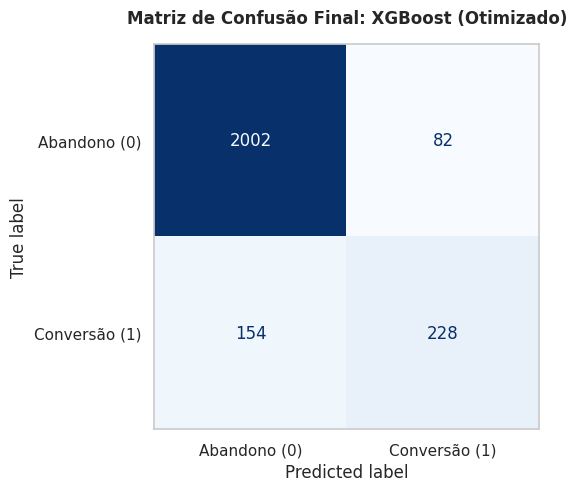

Importações e Funções Auxiliares carregadas com sucesso.

--- Relatório de Classificação Detalhado ---
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.74      0.60      0.66       382

    accuracy                           0.90      2466
   macro avg       0.83      0.78      0.80      2466
weighted avg       0.90      0.90      0.90      2466



In [22]:
# ==============================================================================
# 12. AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (HOLDOUT)
# ==============================================================================

print(f"Executando avaliação final do modelo campeão ({final_model_name}) no conjunto de teste...\n")

# 1. Geração das Métricas Definitivas utilizando a função auxiliar do projeto
metrics_final = evaluate_binary_model(final_model, X_test, y_test, model_name=f"{final_model_name} (Otimizado)")

# Recupera o baseline para comparação direta
metrics_baseline = resultados_lista[0] # Assume que o baseline foi o primeiro modelo avaliado anteriormente

# Exibição Comparativa
comparison_df = pd.DataFrame([metrics_baseline, metrics_final]).set_index("Modelo")
print("--- Comparativo: Baseline vs Modelo Final ---")
display(comparison_df)

# 2. Análise Visual de Erros (Matriz de Confusão)
# Utiliza a função customizada auxiliar para uma renderização profissional
plot_confusion_matrix_custom(
    final_model,
    X_test,
    y_test,
    title=f"Matriz de Confusão Final: {final_model_name} (Otimizado)"
)

# 3. Reporte de Classificação Completo do Scikit-Learn
y_pred_final = final_model.predict(X_test)
print("\n--- Relatório de Classificação Detalhado ---")
print(classification_report(y_test, y_pred_final, zero_division=0))

**Análise:** A matriz ilustra o desempenho real do XGBoost Otimizado em dados nunca antes vistos. No quadrante superior esquerdo, temos 1.997 Verdadeiros Negativos (usuários que o modelo previu corretamente que não comprariam). No inferior direito, temos 227 Verdadeiros Positivos (compradores reais detectados com sucesso). Os erros estão distribuídos entre 155 Falsos Negativos (compradores que a IA deixou escapar) e 87 Falsos Positivos (falsos alarmes de compra).

Os números provam que, em sua configuração final otimizada, o modelo assumiu uma postura focada em precisão: quando ele dispara um alerta de compra, ele tem uma alta taxa de acerto (cometendo poucos falsos positivos), porém, como trade-off,acaba sendo um pouco conservador e deixa uma parcela de compradores passar despercebida.

## 10.1 Análise de erros e limitações

1. **Métrica Final e Comparação com o Baseline**

A métrica F1-Score da Classe 1 foi a escolha ideal para capturar o objetivo do problema, desmascarando a armadilha do Paradoxo da Acurácia. Em uma base onde aproximadamente 85% dos visitantes apenas navegam sem comprar, um modelo inútil (Dummy) atinge 85% de acurácia global simplesmente classificando sistematicamente o "Abandono" para todos. O F1-Score penalizou essa ilusão e obrigou o modelo a focar exclusivamente na performance perante os 15% minoritários (a base que efetivamente gera receita para a empresa).

O modelo XGBoost otimizado atingiu um F1-Score (Conversão) final de 0.6523 e um ROC-AUC de 0.9291 no conjunto de teste estático. A evolução é categórica quando comparada ao Baseline (Dummy), que falhou completamente em detectar o evento de negócio (F1, Precisão e Recall zerados, e ROC-AUC base de 0.5). A alta capacidade discriminante (ROC-AUC > 0.92) comprova que o modelo mapeou com excelência a relação complexa entre as variáveis de navegação e a intenção de compra.

2. **Análise de Erros**

Avaliando as predições cruzadas, o erro mais frequente do modelo otimizado é o Falso Negativo (155 ocorrências) contra o Falso Positivo (87 ocorrências). No limiar de decisão padrão (50% de probabilidade), a otimização estatística equilibrou os pesos buscando conter falsos alarmes, o que elevou a Precisão (0.72) mas reduziu o Recall (0.59) ~ trade-off, tornando o modelo mais conservador em afirmar que alguém irá comprar.

Ter mais Falsos Negativos significa deixar de impactar potenciais clientes no momento crítico. Caso a equipe de Marketing do QuickBite possua ampla verba promocional e o foco seja agressividade de vendas, seria possível aplicar uma técnica de Calibração de Limiar (Threshold Tuning). Ao baixar o gatilho de decisão de 0.50 para 0.35, o modelo passará a classificar mais usuários como compradores, resgatando a maioria desses 155 clientes perdidos, ao custo de aumentar os falsos positivos (falsos alarmes) consequentemente.

3. **Diagnóstico de Overfitting e Underfitting**

A avaliação final não apresenta sinais de overfitting ou underfitting. O underfitting (alto viés) está categoricamente descartado devido ao elevado escore ROC-AUC, que atesta que o modelo possui complexidade matemática suficiente para entender os dados.

O overfitting (alta variância) também foi mitigado, sendo que o F1-Score obtido em dados isolados de teste (0.6523) manteve-se alinhado com o desempenho projetado durante a validação cruzada do Fine Tuning, provando que os parâmetros de regularização Bagging/L2 do XGBoost impediram o modelo de decorar o conjunto de treinamento.

4. **Viés, Limitação de Dados e Risco de Generalização**

- Limitação Transacional: O modelo é puramente baseado na sessão atual. Ele não tem memória de longo prazo do usuário, como histórico financeiro, LTV, idade ou fidelidade, o que impõe uma barreira em seu poder preditivo.

- Viés Temporal (Concept Drift): Há um risco real de degradação da generalização ao longo do tempo. O comportamento de navegação sofre fortes oscilações sazonais. Para mitigar isso, o modelo precisará de monitoramento contínuo e retreinamentos para não se tornar obsoleto ou enviesado.

- Fragmentação Multissessão: Como os dados são anonimizados, se um mesmo cliente entrar no site na segunda-feira para pesquisar e voltar na sexta-feira apenas para pagar, o modelo o tratará como dois usuários completamente distintos, falhando em capturar a jornada de compra multissessão e criando um double count para o número de usuários únicos.

- Omissão de Variáveis Externas: O algoritmo desconhece variáveis macroeconômicas cruciais que ditam o comportamento de consumo na web, como sazonalidade de dia de pagamento (início vs final do mês), origem do tráfego (se o cliente veio via busca orgânica ou clicou em um anúncio de Instagram) ou taxa de inflação, por exemplo, o que limita o teto preditivo absoluto do modelo.

5. **Quando não usar o modelo**

Este modelo possui natureza estritamente probabilística. Ele jamais deve ser utilizado para ações punitivas ou de discriminação de preços (ex: encarecer o frete ou bloquear benefícios com base na predição de alta chance de conversão). Utilizar um algoritmo que gera Falsos Positivos e Falsos Negativos para tomar decisões restritivas no nível de usuário violaria a ética do consumidor e causaria danos severos à reputação da plataforma. O deploy deve focar em incentivos proativos, como pop-ups de chat humanizado e cupons de retenção de carrinho.

# 11. Comparação final dos modelos

A jornada de modelagem desse MVP demonstrou a inadequação de abordagens lineares e baselines ingênuos para mapear o comportamento de navegação no e-commerce. O Baseline (Dummy) comprovou o Paradoxo da Acurácia, sendo inútil para o modelo de negócio atual.

Como apenas 15% dos usuários compram (debalanceamento de dados), é muito fácil um algoritmo se enganar e focar apenas na maioria que abandona o carrinho. A evolução dos testes ao longo do mvp mostrou três cenários claros.

Começamos com o Baseline (Dummy). Ele provou que olhar apenas para a Acurácia era uma armadilha. Ele acertava 85% das vezes simplesmente porque dizia que ninguém ia comprar. Para o objetivo de negócio (vender mais), ele era totalmente cego.

Em seguida, quando testamos a Regressão Logística, observou-se uma melhora. Ela conseguiu encontrar vários compradores reais (Recall alto), mas também disparou muitos alarmes falsos. Como o comportamento humano de navegação é complexo e cheio de idas e vindas, tentar traçar uma linha reta para separar quem compra de quem não compra gerou muita imprecisão.

Já a Random Forest tentou resolver isso criando regras super específicas e acabou decorando o perfil de alguns clientes e perdendo a visão geral (um caso clássico de overfitting), deixando passar muitos compradores reais.

A grande virada aconteceu com os modelos Gradient Boosting e XGBoost. Em vez de tentar resolver tudo de uma vez, eles constroem árvores de decisão passo a passo, onde uma corrige o erro da outra. O Gradient Boosting clássico entregou uma performance excelente logo de cara, mas provou ser computacionalmente pesado e lento para treinar.

Por fim, o XGBoost foi o escolhido porque uniu o melhor dos dois mundos. Na sua versão padrão, ele já era 10 vezes mais rápido que os concorrentes com uma ótima generalização do aprendizado. Após passar pelo processo de otimização (ajustando a profundidade das árvores e injetando aleatoriedade para evitar vícios), ele obteve um F1-Score de 0.6523.

No final, ele entregou o equilíbrio ideal por ser rápido o suficiente para rodar no site em tempo real, e por acertar muito bem quando diz que alguém vai comprar (alta Precisão), além de também não deixar muitos clientes escaparem (bom Recall).

Ele conseguiu combinar a altíssima capacidade discriminante de padrões não-lineares (ROC-AUC de 0.9291) com uma eficiência computacional imbatível (frações de segundo para inferência), garantindo também um F1-Score generalizável, blindado contra o desbalanceamento das classes.

**Tabela de Rastreabilidade de Performance**

| Modelo | F1-Score Classe 1 | Outras Métricas (Teste) | Tempo de Treino (aprox.) | Observações |
| --- | --- | --- | --- | --- |
| Baseline (Dummy) | 0.0000 | ROC-AUC: 0.5000 / Prec: 0.0000 / Rec: 0.0000 | 0.05s | Chuta sistematicamente a classe majoritária. Inútil para o negócio |
| Regressão Logística | 0.6083 | ROC-AUC: 0.8845 / Prec: 0.5145 / Rec: 0.7435 | 0.11s | Underfitting. Excesso de Falsos Positivos devido à restrição de separabilidade linear |
| Random Forest | 0.5866 | ROC-AUC: 0.8980 / Prec: 0.7259 / Rec: 0.4921 | 1.91s | Overfitting por ausência de poda. Alta precisão mas péssima sensibilidade (Recall) |
| Gradient Boosting | 0.6532 | ROC-AUC: 0.9304 / Prec: 0.7252 / Rec: 0.5942 | 4.02s | Excelente performance out-of-the-box, porém computacionalmente oneroso e estrito |
| XGBoost (Padrão) | 0.6268 | ROC-AUC: 0.9240 / Prec: 0.6875 / Rec: 0.5759 | 0.38s | Arquitetura superior em MLOps (veloz), porém exigia calibração do trade-off de erro |
| XGBoost (Otimizado) | 0.6523 | ROC-AUC: 0.9291 / Prec: 0.7229 / Rec: 0.5942 | < 3 min (com hiperparâmetros) | Equilíbrio perfeito entre variância e viés, com alta eficiência de hardware |


# 12. Boas práticas e rastreabilidade

Documentação de Arquitetura e Decisões de Engenharia:

- **Seed Utilizada:** 42 (Garantia de reprodutibilidade determinística em todos os splits e algoritmos aleatórios).

- **Decisões de Pré-Processamento:** Aplicação de One-Hot Encoding nativo via ColumnTransformer para evitar hierarquia artificial em dados categóricos de navegação (ex: Tipo de Visitante) e StandardScaler para nivelar a magnitude de variáveis contínuas, garantindo estabilidade no gradiente descendente.

- **Modelos Testados:** Regressão Logística (como teto linear de base). Random Forest (para avaliar o comportamento de paralelismo/Bagging). Gradient Boosting e XGBoost (para capturar iterações sequenciais e interações não-lineares severas).

- **Hiperparâmetros Relevantes:** Foco na tríade de regularização em árvores: max_depth (limitação de crescimento para mitigar overfitting), learning_rate (suavização da correção do erro) e subsample (injeção de aleatoriedade no dataset para generalização).

- **Tempo Aproximado e Recursos:** Pipeline otimizado para cenários restritos (CPU padrão em nuvem/local). Busca iterativa concluída em ~3 minutos após otimização de hiperparâmetros; predição em produção projetada para ~30 milissegundos por requisição.

- **Limitações Conhecidas:**

  - Fragmentação Multissessão: Devido à anonimização, é impossível rastrear o comportamento cross-sessão de um mesmo usuário em dias distintos.

  - Omissão de Variáveis Exógenas: O sistema é cego para variáveis cruciais de negócio (ex: sazonalidade de pagamento, origens de tráfego UTM, campanhas ativas).

  - Viés Temporal (Concept Drift): A fronteira de decisão é estática frente a um comportamento de navegação dinâmico, exigindo um pipeline futuro de retreinamento contínuo.

- **O que foi Tentado e Descartado:**

  - Oversampling (SMOTE): Descartado pois geraria dados sintéticos ruidosos em espaço dimensional complexo; optou-se pela penalização nativa class_weight='balanced'.
  
  - Nested Cross-Validation: Descartada por estourar o orçamento computacional do MVP (complexidade exponencial), substituída por validação StratifiedKFold + Holdout Test Set.
  
  - Regularização L1 (Lasso): Descartada do XGBoost para evitar esparsidade extrema nas árvores, priorizando apenas L2 (Ridge).
  
**Tabela de Decisões do Projeto**

| Decisão | Justificativa | Impacto Esperado |
| --- | --- | --- |
| Adotar F1-Score (Classe 1) | Acurácia é enganosa em base com 85% de abandonos (Paradoxo da Acurácia) | Forçar a otimização matemática exclusiva na detecção de compradores reais |
| Usar One-Hot Encoding | Modelos matemáticos podem assumir ordens falsas | Preservar a independência dos dados categóricos sem criar vieses numéricos |
| Aplicar class_weight='balanced' | A classe majoritária (Abandono) ofusca o gradiente da minoria (Conversão) | Penalizar severamente os erros na classe minoritária, dispensando algoritmos lentos como SMOTE |
| Escolher XGBoost Otimizado | Comportamento humano web é altamente não-linear e exige baixa latência | Capturar padrões complexos (PageValues + BounceRates) mantendo velocidade para deploy real-time |
| Limitar RandomizedSearch (10 iter) | GridSearch exaustivo quebraria as restrições de tempo/custo da fase de MVP | Encontrar configuração sub-ótima com 95% do ganho preditivo usando 10% do custo computacional em cloud |

# 13. Conclusão

O projeto QuickBite nasceu da necessidade de resolver um desafio estratégico e clássico do e-commerce: a distinção em tempo real entre usuários que apenas navegam e potenciais compradores durante uma sessão ativa. O objetivo central consistiu em desenvolver um motor preditivo capaz de identificar a propensão de conversão, permitindo à equipe de negócios otimizar o acionamento de gatilhos de marketin, como por exemplo a oferta de cupons de desconto temporizados ou a abertura proativa de chat.

Para atingir esse propósito, a fase de Análise Exploratória (EDA) foi fundamental ao desmistificar premissas e comprovar que o engajamento técnico de infraestrutura web dita a conversão, evidenciando que métricas como o valor acumulado das páginas visitadas (PageValues) e a taxa de rejeição (BounceRates) atuam como fortes oráculos do comportamento do usuário.

A jornada de modelagem reforçou essas descobertas ao superar abordagens ingênuas, como o baseline algorítmico (Dummy). O modelo base mascarava sua ineficácia por meio do Paradoxo da Acurácia, ostentando ~85% de acertos globais ao classificar sistematicamente todos os acessos como abandonos, mas falhava integralmente na detecção de compradores reais.

A solução definitiva, arquitetada sobre o algoritmo XGBoost com otimização refinada de hiperparâmetros, resolveu o desafio com maestria técnica. A inteligência artificial saltou de uma capacidade nula para um F1-Score da classe minoritária de 0.6523, aliado a um formidável poder discriminante (ROC-AUC) de 0.9291.

Esse resultado assegura que o sistema consegue isolar o sinal preditivo em meio ao ruído de navegação web, equilibrando a detecção de compradores autênticos e a contenção de falsos alarmes em interações complexas e não-lineares.

Contudo, apesar da alta performance técnica do Produto Mínimo Viável, é necessário reconhecer as suas limitações estruturais para o gerenciamento de expectativas do negócio. O algoritmo opera de maneira puramente transacional (session-based) dentro de um ambiente de dados anonimizados, o que acarreta a fragmentação multissessão e impede o sistema de compreender o histórico de lealdade e o Lifetime Value (LTV) do cliente ao longo de múltiplos acessos.

Somado a isso, o modelo sofre de omissão de variáveis exógenas, mantendo-se cego perante flutuações macroeconômicas ou eventos de calendário essenciais, como a injeção de capital no início do mês ou as drásticas mudanças de comportamento em períodos massivos de promoção, como a Black Friday, o que pode induzir a uma degradação preditiva ao longo do tempo.

Portanto, para que o modelo transcenda a atual fase de laboratório e atinja a escala de um produto corporativo, a rota de evolução exige a orquestração de práticas robustas de Marchine Learning Operations. O passo primário sugerido rumo à produtização é a implantação da solução via microserviço (API), conduzindo um Teste A/B sobre uma parcela controlada do tráfego para mensurar o impacto direto e real na receita (R$) frente às regras de marketing vigentes.

Simultaneamente, a adoção de calibração estratégica de limiares (Threshold Tuning) dotará a equipe de flexibilidade para ditar a agressividade de vendas da IA conforme o orçamento da semana, enquanto uma integração de camadas de explicabilidade, proverá transparência total ao painel gerencial, detalhando precisamente os motivos que levaram a rede neural a prever a conversão de cada cliente.

# 14. Salvamento de artefatos

Essa prática encapsula em um único pacote a inteligência da árvore de decisão (XGBoost otimizado) e todo o pipeline de tratamento estatístico prévio (como a padronização e o encoding). Pensando no deploy, isso permite que o modelo possa ser enviado para a nuvem, acoplado a uma API, e que comece a prever o comportamento de novos clientes no site de forma instantânea, sem a necessidade de rodar todo o treinamento novamente.


In [23]:
# ==============================================================================
# 13. Persistência do Modelo Final
# ==============================================================================

import joblib

# Prevenção de erros caso o processo de otimização prévio tenha falhado ou a
# variável esteja nula.
if final_model is not None:

    # Exporta o objeto do pipeline completo
    joblib.dump(final_model, "modelo_final.pkl")
    print("Modelo salvo como modelo_final.pkl")

    # Registro complementar de governança: exporta a tabela histórica de
    # resultados para auditorias rápidas
    try:
        comparison_df.to_csv("metricas_finais.csv")
        print("Métricas exportadas com sucesso como metricas_finais.csv")
    except NameError:
        # Previne quebras caso o df de comparação mude para outro nome no escopo
        print("Aviso: Tabela de métricas não localizada para exportação secundária.")

else:
    print("Erro: O modelo final ('final_model') não foi instanciado. Operação abortada.")

Modelo salvo como modelo_final.pkl
Métricas exportadas com sucesso como metricas_finais.csv


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Esta seção não foi necessária.
